In [26]:
# Ran on Colab with an L4 GPU, there are no other requirements, except to hit the run all button

!pip install opencv-python
!pip install tensorflow
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install sklearn
!pip install kagglehub

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [27]:
# Download GTSRB database from kaggle

import kagglehub

DATA_PATH = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", DATA_PATH)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [28]:
# Ensure our L4 GPU is detected

import tensorflow as tfc
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [29]:
# Batch our imports

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf

from pathlib import Path
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model, Sequential

In [30]:
# Load GTSRB dataset from kaggle we previously downloaded in above cell
def load_gtsrb_data(csv_file, base_path, size=(64, 64)):
    df = pd.read_csv(csv_file)
    images = []
    labels = []

    print(f"Loading data from {csv_file}...")
    for index, row in df.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        try:
            img = Image.open(img_path).convert('RGB')
            # Resize for compatibility with CNN architecture for prediction
            img = img.resize(size)
            images.append(np.array(img))
            labels.append(row['ClassId'])
        except Exception as e:
            continue

    # Return normalized array
    return np.array(images).astype('float32') / 255.0, np.array(labels)

# Our CNN we will be using as our classifier for this project
# We use the # of classes in the GTSRB and our normalized sized as default
def get_classifier(num_classes=43, input_shape=(64, 64, 3)):
    model = Sequential([
        layers.Input(shape=input_shape),
        # Use ReLu activation function with Conv2D layers to learn features
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        # Use max pooling to downsample resolution
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # 2D -> 1D for classification
        layers.Flatten(),
        # Combines all hidden features for classification
        layers.Dense(128, activation='relu'),
        # Dropout layer to prevent overfitting
        layers.Dropout(0.5),
        # Softmax for final classification step
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Load train/test datasets
train_csv = os.path.join(DATA_PATH, "Train.csv")
test_csv = os.path.join(DATA_PATH, "Test.csv")
X_train, y_train = load_gtsrb_data(train_csv, DATA_PATH)
X_test, y_test = load_gtsrb_data(test_csv, DATA_PATH)


# Utilize MSE + SSIM loss
# Reasoning being that MSE is preferred for maintaining image structure, but if
# used alone, the de-noiser may perform well, but could produce very blurry
# output that the classifier may struggle with
# This is used in the autoencoder used for recovery
def mixed_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mse + (0.1 * ssim) # Balance the two

# Use adam, standard optimizer for deep learning tasks
# Use sparse_categorical_crossentropy as this is a multi class prediction model
# Accuracy is used here, but ultimately the classifier is tested using a number of metrics later.
classifier = get_classifier()
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
classifier.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# 3. Save the model for re-use
classifier.save("gtsrb_classifier_model.keras")
print("Model saved successfully as gtsrb_classifier_model.keras")

Loading data from /kaggle/input/gtsrb-german-traffic-sign/Train.csv...
Loading data from /kaggle/input/gtsrb-german-traffic-sign/Test.csv...
Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5996 - loss: 1.4235 - val_accuracy: 0.8476 - val_loss: 0.5095
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8673 - loss: 0.4298 - val_accuracy: 0.9070 - val_loss: 0.3577
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9123 - loss: 0.2853 - val_accuracy: 0.9377 - val_loss: 0.2337
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9327 - loss: 0.2135 - val_accuracy: 0.9321 - val_loss: 0.2377
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9442 - loss: 0.1747 - val_accuracy: 0.9402 - val_loss: 0.2136
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9536 - loss: 0.1425 - val_accuracy: 0.9466 - val_loss: 0.2238
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9603 - loss: 0.1242 - v

In [31]:
# Function to generate random noise for our U-Net


def generate_random_noise_batch(clean_batch):
    dice_roll = np.random.random()

    if dice_roll < 0.3:
        # 30% Clean
        return clean_batch
    elif dice_roll < 0.8:
        # 50% light noise
        std_dev = np.random.uniform(0.01, 0.05)
    else:
        # 20% Heavy noise
        std_dev = np.random.uniform(0.1, 0.2)

    noise = tf.random.normal(shape=clean_batch.shape, mean=0.0, stddev=std_dev)
    return tf.clip_by_value(clean_batch + noise, 0.0, 1.0)

x_train_noisy = generate_random_noise_batch(X_train)
x_test_noisy = generate_random_noise_batch(X_test)

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# The use of a U-Net (vs a standard Autoencoder) was motivated by the poor
# performance of standard autoencoders to solve the project goal.
# In a standard Autoencoder, downsampling layers force the model to discard
# high-frequency spatial details, like the sharp edges of numbers on a sign,
# making reconstruction difficult for heavily noised images.
#
# The U-Net solves this by using skip connections to propagate low-level/
# high-resolution features from the encoder directly to the decoder.
# This maintains the structural of the traffic sign images
# while the standard AE layers focus on learning the latent representation of the
# noise in the images.
# On top of that, we're also not trying to predict the entire image, but instead
# only trying to predict the noise in the image and subtracting that from the output.
def build_unet_base(input_shape=(64, 64, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck layer
    b1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)

    # Decoder with Skip Connections
    u1 = layers.UpSampling2D((2, 2))(b1)
    # We're adding the first decoder layer with the second encoder layer (Both inner layers)
    concat1 = layers.concatenate([u1, c2])
    d1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat1)

    u2 = layers.UpSampling2D((2, 2))(d1)
    # We're adding the second decoder layer with the first encoder layer (Both outer layers)
    concat2 = layers.concatenate([u2, c1])
    d2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(concat2)

    # We use a linear activation to ensure we're predicting the noise
    noise_out = layers.Conv2D(3, (3, 3), activation='linear', padding='same')(d2)

    return Model(inputs, noise_out)

# 2. De-noising wrapper
def build_residual_autoencoder(input_shape=(64, 64, 3)):
    base_unet = build_unet_base(input_shape)
    inputs = Input(input_shape)

    # Make noise prediction
    predicted_noise = base_unet(inputs)

    # Subtract the predicted noise from the noised image
    denoised = layers.Subtract()([inputs, predicted_noise])

    # Ensure we're maintaing the normalized pixel values
    outputs = layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0))(denoised)

    return Model(inputs, outputs, name="Residual_U-Net")

# 3. Build the model
autoencoder = build_residual_autoencoder()
autoencoder.compile(optimizer='adam', loss=mixed_loss)

In [33]:
# Train the model
autoencoder.fit(x_train_noisy, X_train,
                epochs=10,
                batch_size=64,
                validation_data=(x_test_noisy, X_test))

# Test predictions on five sample images for human verification
decoded_imgs = autoencoder.predict(x_test_noisy[:5], verbose=0)

Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0010 - val_loss: 0.0026
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.8381e-04 - val_loss: 0.0030
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.6426e-04 - val_loss: 0.0029
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.4714e-04 - val_loss: 0.0028
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.3557e-04 - val_loss: 0.0029
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.2723e-04 - val_loss: 0.0030
Epoch 9/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.2055e-04 - val_loss: 0.0024
Epoch 10/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 9.1430e-04 - val_loss: 0.0033


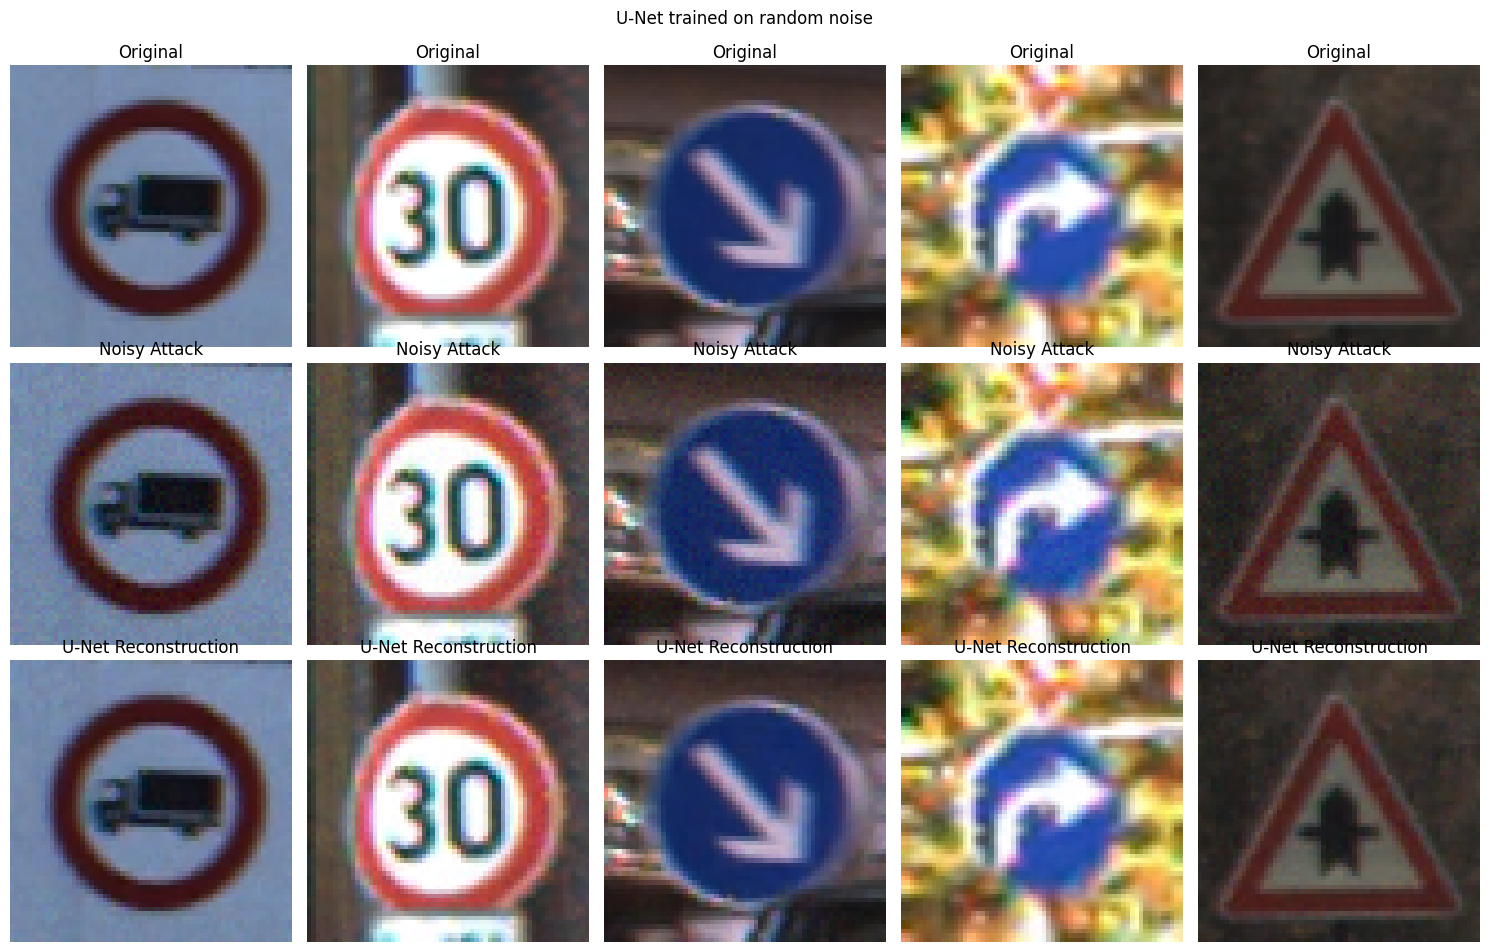

In [63]:
def visualize_unet_results(clean, noisy, reconstructed, n=5):
    plt.figure(figsize=(15, 10))
    for i in range(n):
        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(clean[i])
        plt.title("Original")
        plt.axis("off")

        # Noised
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy[i])
        plt.title("Noisy Attack")
        plt.axis("off")

        # Model performance
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(decoded_imgs[i])
        plt.title("U-Net Reconstruction")
        plt.axis("off")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("U-Net trained on random noise")
    plt.show()

# Visualize 5 samples
visualize_unet_results(X_test, x_test_noisy, decoded_imgs, n=5)

In [35]:
# Use SparseCategoricalCrossentropy because labels are multi class, not one hot
# This code was modeled after https://www.tensorflow.org/tutorials/generative/adversarial_fgsm
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

def create_adversarial_pattern(model, input_image, y_true):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = model(input_image)

        loss = loss_object(y_true, prediction)

    gradient = tape.gradient(loss, input_image)

    signed_grad = tf.sign(gradient)
    return signed_grad

In [36]:
# Function wraps create_adversarial_pattern and performs a dice roll to determine
# how noised an image is going to be. This allows the U-Net to see the spectrum
# from clean to heavily noised images.
def generate_fgsm_in_batches(model, data, labels, batch_size=64, epsilon=None):
    adv_data = []

    for i in range(0, len(data), batch_size):
        batch_x = tf.convert_to_tensor(data[i : i + batch_size], dtype=tf.float32)
        batch_y = tf.convert_to_tensor(labels[i : i + batch_size], dtype=tf.int32)

        # If provided, consistenly use epsilon passed.
        if epsilon is not None:
            current_eps = epsilon
        # If not provided, provide distribution of epsilon values
        else:
            dice_roll = np.random.random()
            if dice_roll < 0.3:
                current_eps = 0.0
            elif dice_roll < 0.8:
                current_eps = np.random.uniform(0.01, 0.05)
            else:
                current_eps = np.random.uniform(0.1, 0.2)

        if current_eps > 0:
            signed_grad = create_adversarial_pattern(model, batch_x, batch_y)
            adv_batch = batch_x + current_eps * signed_grad
            adv_batch = tf.clip_by_value(adv_batch, 0, 1)
        else:
            adv_batch = batch_x

        adv_data.append(adv_batch.numpy())

    return np.concatenate(adv_data, axis=0)

# Generate the adversarial training data in chunks
x_train_adversarial = generate_fgsm_in_batches(classifier, X_train, y_train, batch_size=64)
x_test_adversarial = generate_fgsm_in_batches(classifier, X_test, y_test, batch_size=64)

In [37]:
# Standard AE to compare to U-Net architecture
# DAE = Denoising AutoEncoder
def build_standard_dae(input_shape=(64, 64, 3)):
    model = Sequential([
        layers.Input(shape=input_shape),
        # Encoder
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Decoder
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
    ], name="Standard_DAE")
    return model

standard_dae = build_standard_dae()
standard_dae.compile(optimizer='adam', loss=mixed_loss)

print("Training standard autoencoder for comparison...")
# Train against FGSM images
standard_dae.fit(x_train_adversarial, X_train, epochs=10, batch_size=64, verbose=0)

Training standard autoencoder for comparison...


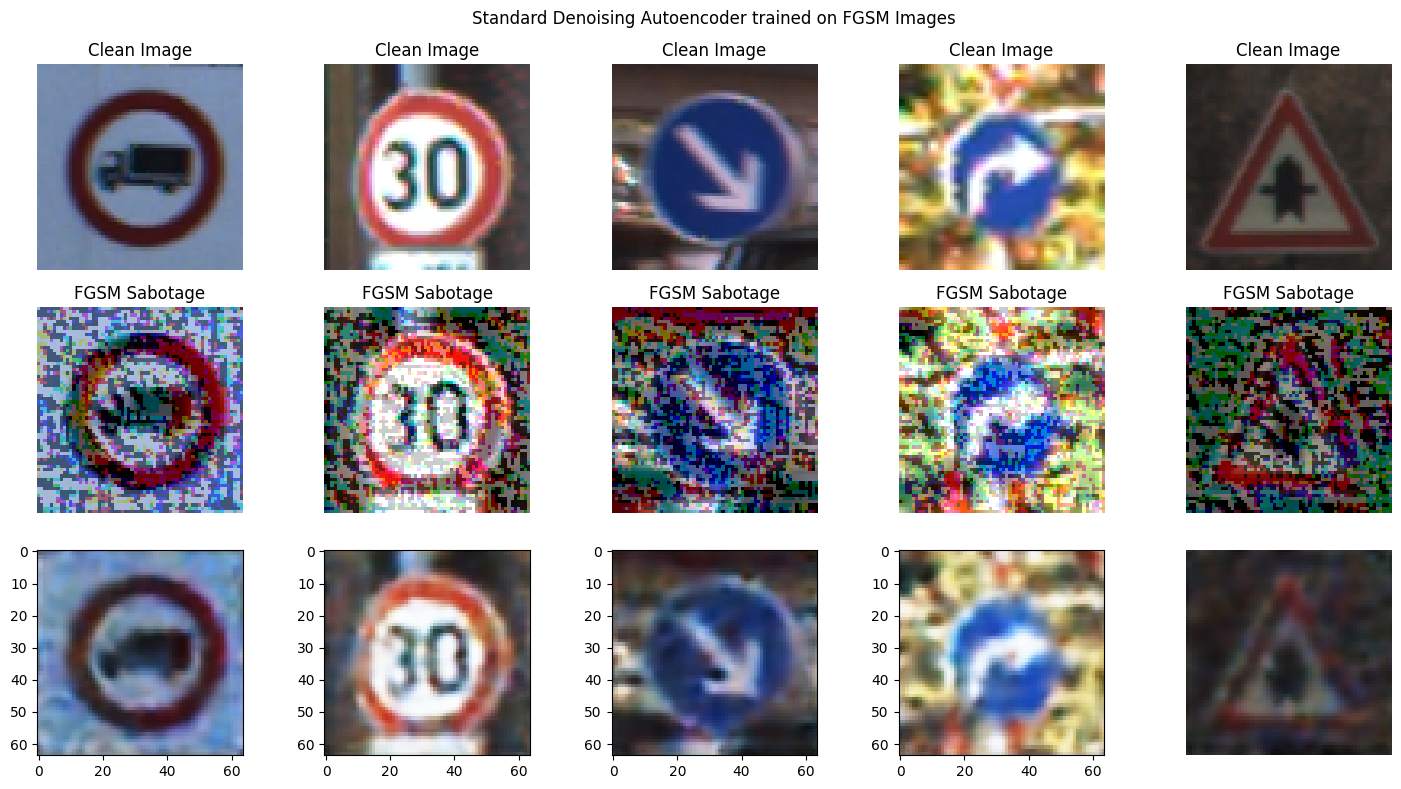

In [64]:
# Visualize FGSM Denoising

def visualize_denoising(model, clean_data, noisy_data, n=5):
    # Predict the denoised images
    denoised_data = model.predict(noisy_data[:n], verbose=0)

    plt.figure(figsize=(15, 8))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(clean_data[i])
        plt.title("Clean Image")
        plt.axis("off")

        # 2. Adversarially Noised (FGSM)
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy_data[i])
        plt.title(f"FGSM Sabotage")
        plt.axis("off")

        # 3. Denoised Reconstruction
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(denoised_data[i])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("Standard Denoising Autoencoder trained on FGSM Images")
    plt.axis("off")
    plt.show()

# Run the visualization
visualize_denoising(standard_dae, X_test, x_test_adversarial, n=5)

In [39]:
# Create U-Net
adversarial_autoencoder = build_residual_autoencoder()
adversarial_autoencoder.compile(optimizer='adam', loss=mixed_loss)

In [40]:
# Train U-Net with FGSM images
adversarial_autoencoder.fit(x_train_adversarial, X_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test_adversarial, X_test))

Epoch 1/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 0.0102 - val_loss: 0.0076
Epoch 2/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0065 - val_loss: 0.0061
Epoch 3/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 4/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 5/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 6/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 7/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 8/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 9/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0031 - val_loss: 0.0032


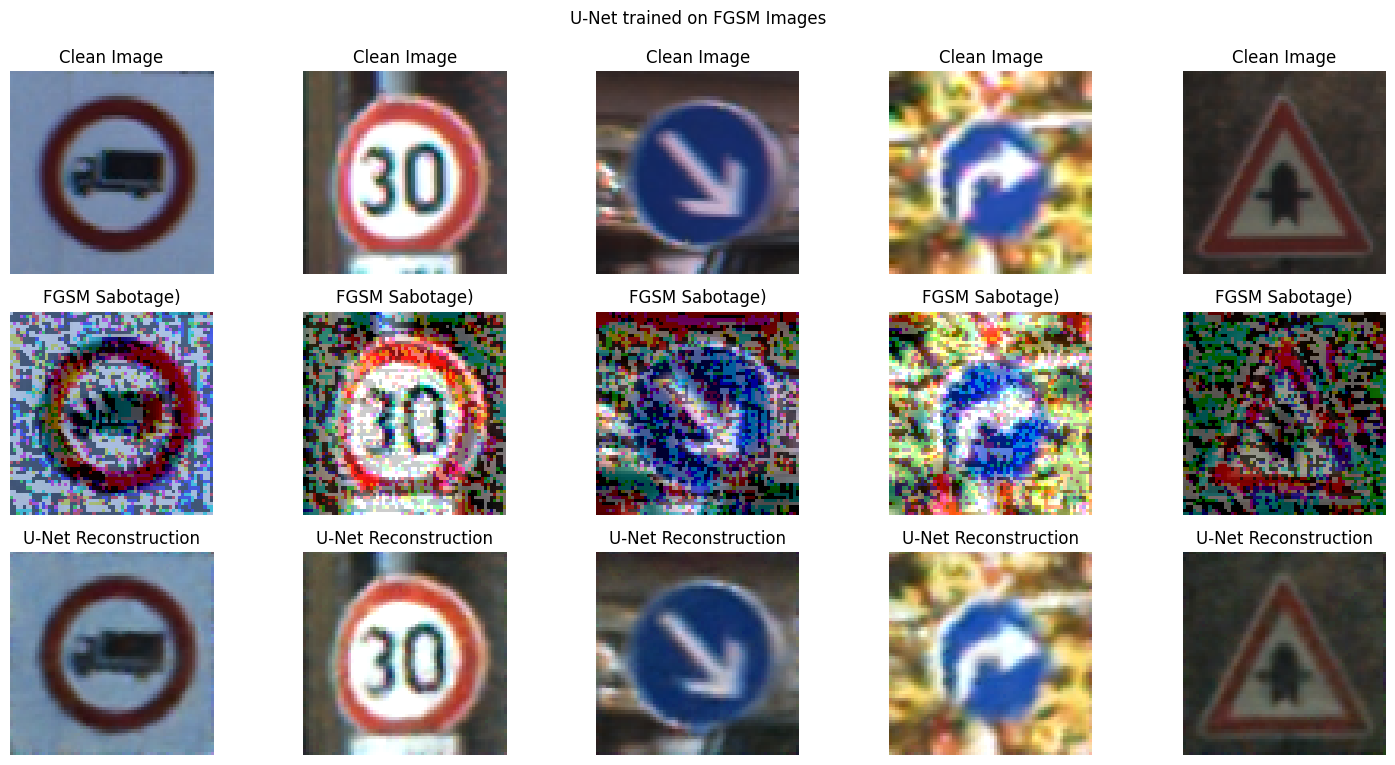

In [65]:
# Visualize FGSM Denoising

def visualize_denoising(model, clean_data, noisy_data, n=5):
    # Predict the denoised images
    denoised_data = model.predict(noisy_data[:n], verbose=0)

    plt.figure(figsize=(15, 8))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(clean_data[i])
        plt.title("Clean Image")
        plt.axis("off")

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy_data[i])
        plt.title(f"FGSM Sabotage)")
        plt.axis("off")

        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(denoised_data[i])
        plt.title("U-Net Reconstruction")
        plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("U-Net trained on FGSM Images")
    plt.axis("off")
    plt.show()

# Show visualization
visualize_denoising(adversarial_autoencoder, X_test, x_test_adversarial, n=5)

In [42]:
# Apply linear blur to compare to AE performance
def apply_linear_blur(data, kernel_size=(3, 3)):
    blurred_data = []
    for img in data:
        # Standard Gaussian Blur
        blur = cv2.GaussianBlur(img, kernel_size, 0)
        blurred_data.append(blur)
    return np.array(blurred_data)

# Generate the blurred version of the adversarial test images
x_test_blurred = apply_linear_blur(x_test_adversarial, kernel_size=(3, 3))

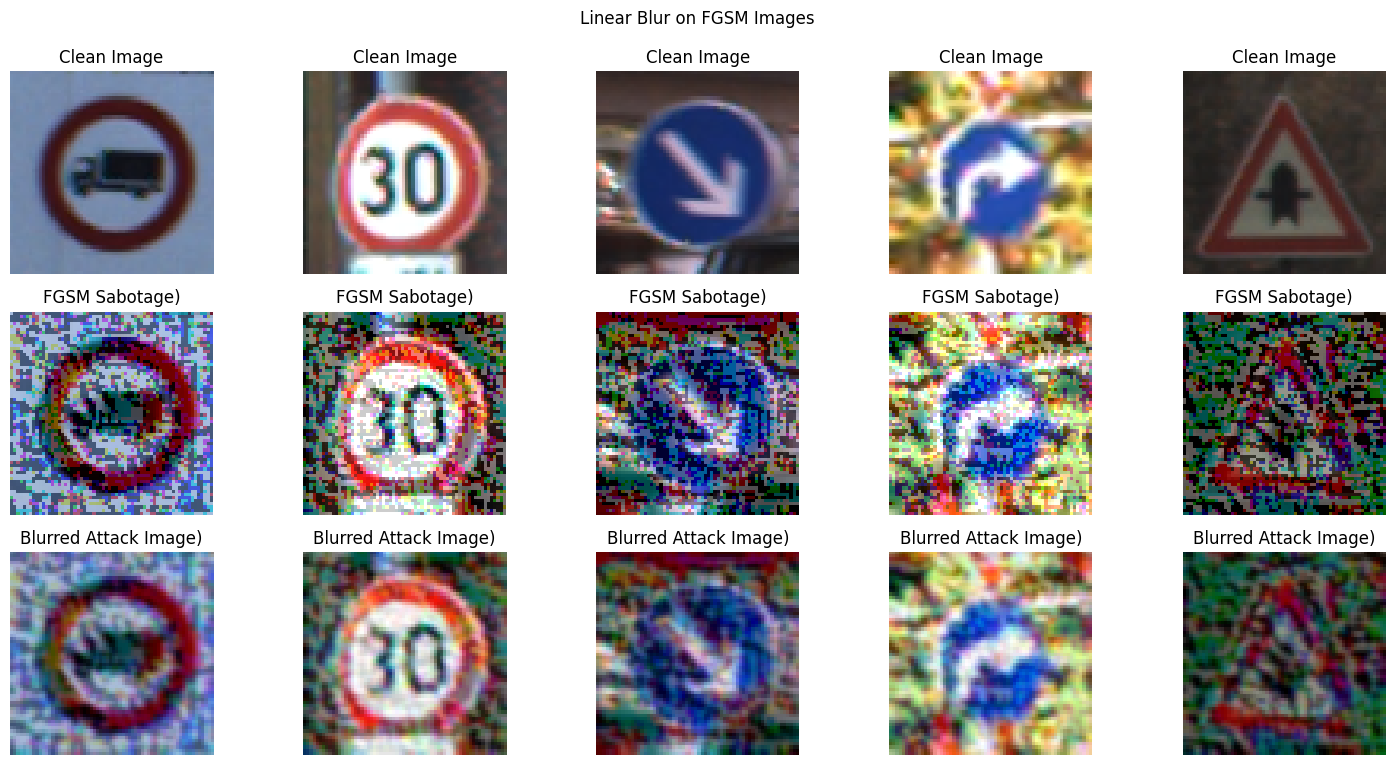

In [66]:
# Visualize FGSM Denoising

def visualize_denoising_blur(clean_data, noisy_data, blurred_data, n=5):

    plt.figure(figsize=(15, 8))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(clean_data[i])
        plt.title("Clean Image")
        plt.axis("off")

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy_data[i])
        plt.title(f"FGSM Sabotage)")
        plt.axis("off")

        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(blurred_data[i])
        plt.title("Blurred Attack Image)")
        plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle("Linear Blur on FGSM Images")
    plt.axis("off")
    plt.show()

# Show visualization
visualize_denoising_blur(X_test, x_test_adversarial, x_test_blurred, n=5)

In [55]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Constants
eps_val = 0.02

# Generate Random Noise for comparison
def add_random_noise(data, epsilon=0.02):
    noise = np.random.normal(0, epsilon, data.shape)
    return np.clip(data + noise, 0, 1)

# Get metrics for a given model/data
def get_detailed_metrics(classifier_model, data, labels, epsilon):
    preds = classifier_model.predict(data, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    return {
        "Sabotage (epsilon)": epsilon,
        "Accuracy": accuracy_score(labels, pred_labels),
        "F1 (Macro)": f1_score(labels, pred_labels, average='macro'),
        "Precision": precision_score(labels, pred_labels, average='macro', zero_division=0),
        "Recall": recall_score(labels, pred_labels, average='macro', zero_division=0)
    }

# Benchmarks for classifier performance against attacks (no defense)
x_test_random = add_random_noise(X_test, epsilon=eps_val)

table1_scenarios = [
    ("Clean Baseline", X_test, 0.0),
    ("Random Noise", x_test_random, eps_val),
    ("FGSM Sabotage", x_test_adversarial, eps_val)
]

table1_data = []
for name, data, eps in table1_scenarios:
    m = get_detailed_metrics(classifier, data, y_test, eps)
    m["Scenario"] = name
    table1_data.append(m)

df_vuln = pd.DataFrame(table1_data)[["Scenario", "Sabotage (epsilon)", "Accuracy", "F1 (Macro)"]]

x_test_denoised_gen = autoencoder.predict(x_test_adversarial, verbose=0)
x_test_denoised_ae = standard_dae.predict(x_test_adversarial, verbose=0)
x_test_denoised_adv = adversarial_autoencoder.predict(x_test_adversarial, verbose=0)

# Defense evaluation (VS FGSM)
defense_scenarios = [
    ("No Defense", x_test_adversarial),
    ("Linear Blur", x_test_blurred),
    ("General DAE", x_test_denoised_gen),
    ("Standard AE", x_test_denoised_ae),
    ("Adversarial U-Net", x_test_denoised_adv)
]

table2_data = []
for name, data in defense_scenarios:
    m = get_detailed_metrics(classifier, data, y_test, eps_val)
    m["Scenario"] = name
    table2_data.append(m)0 	Clean Baseline 	0.000 	0.949169 	0.926264
1 	Random Noise 	0.020 	0.944339 	0.922061
2 	FGSM Sabotage 	0.020 	0.510451 	0.474421

# Calculate Recovery Rate (Wrong Prediction on raw -> correct prediction on defense applied.)
clean_f1 = df_vuln.loc[0, "F1 (Macro)"]
attack_f1 = df_vuln.loc[2, "F1 (Macro)"]
df_defense['Recovery Rate (%)'] = df_defense.apply(
    lambda row: ((row['F1 (Macro)'] - attack_f1) / (clean_f1 - attack_f1)) * 100
    if row['Scenario'] != "No Defense" else 0, axis=1
)

# Color formatting for clarity.
print("\n=== Varying noise level comparison ===")
display(df_vuln.style.format({"Sabotage (epsilon)": "{:.3f}"}).background_gradient(cmap='Reds', subset=["F1 (Macro)"]))

print("\n=== Comparing recovery rates ===")
display(df_defense.style.format({"Sabotage (epsilon)": "{:.3f}", "Recovery Rate (%)": "{:.1f}%"})
        .background_gradient(cmap='Greens', subset=["Recovery Rate (%)"]))


=== Varying noise level comparison ===


,Scenario,Sabotage (epsilon),Accuracy,F1 (Macro)
0,Clean Baseline,0.000,0.949169,0.926264
1,Random Noise,0.020,0.944339,0.922061
2,FGSM Sabotage,0.020,0.510451,0.474421



=== Comparing recovery rates ===


,Sabotage (epsilon),Accuracy,F1 (Macro),Precision,Recall,Scenario,Recovery Rate (%)
0,0.020,0.510451,0.474421,0.500990,0.477260,No Defense,0.0%
1,0.020,0.540538,0.506929,0.531778,0.510598,Linear Blur,7.2%
2,0.020,0.517102,0.481138,0.507642,0.483579,General DAE,1.5%
3,0.020,0.666508,0.628690,0.653858,0.627922,Standard AE,34.1%
4,0.020,0.763816,0.724104,0.744459,0.722158,Adversarial U-Net,55.3%


Calculating anomaly scores for ROC (Sample Size 1000)


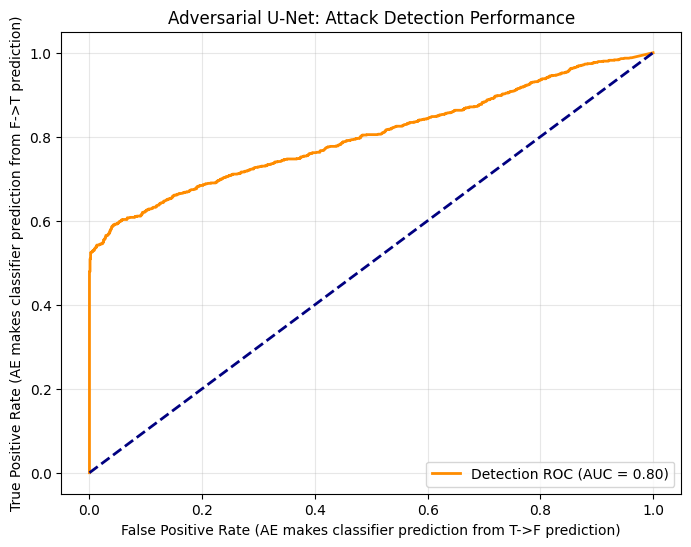

In [56]:
# Calculate ROC of FGSM trained U-Net

def plot_detection_roc(classifier, autoencoder, clean_data, noisy_data):
    # Get prediction probabilities for clean and noisy data
    # Pass both through the autoencoder to see how much the prediction changes

    def get_anomaly_scores(data):
        raw_preds = classifier.predict(data, verbose=0)
        denoised_data = autoencoder.predict(data, verbose=0)
        denoised_preds = classifier.predict(denoised_data, verbose=0)

        # Anomaly Score is the Euclidean distance between the two predictions
        # Higher distance means a higher likelihood of an attack
        return np.linalg.norm(raw_preds - denoised_preds, axis=1)

    print("Calculating anomaly scores for ROC (Sample Size 1000)")
    scores_clean = get_anomaly_scores(clean_data[:1000])
    scores_noisy = get_anomaly_scores(noisy_data[:1000])

    # Combine scores and create true labels (0 for clean, 1 for noisy)
    y_true = np.array([0] * 1000 + [1] * 1000)
    y_scores = np.concatenate([scores_clean, scores_noisy])

    # 2. Calculate ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # 3. Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Detection ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate (AE makes classifier prediction from T->F prediction)')
    plt.ylabel('True Positive Rate (AE makes classifier prediction from F->T prediction)')
    plt.title('Adversarial U-Net: Attack Detection Performance')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Visualize the detection rates
plot_detection_roc(classifier, adversarial_autoencoder, X_test, x_test_adversarial)

In [57]:
def calculate_degradation_rate(classifier, autoencoder, x_clean, y_true):
    # 1. Get initial correct predictions on clean data
    clean_preds = np.argmax(classifier.predict(x_clean, verbose=0), axis=1)
    correct_indices = np.where(clean_preds == y_true)[0]
    total_correct = len(correct_indices)

    if total_correct == 0:
        return 0.0

    # 2. Pass only correct images through the autoencoder
    x_correct_clean = x_clean[correct_indices]
    y_correct_labels = y_true[correct_indices]

    x_reconstructed = autoencoder.predict(x_correct_clean, verbose=0)

    # 3. Check how many are predicated to be the wrong class
    reconstructed_preds = np.argmax(classifier.predict(x_reconstructed, verbose=0), axis=1)
    still_correct = np.sum(reconstructed_preds == y_correct_labels)

    # Degradation Rate: what % of images went from correct prediction to incorrect prediction
    degradation_rate = (1 - (still_correct / total_correct)) * 100
    return degradation_rate

# Calculate for both U-Nets
gen_degradation = calculate_degradation_rate(classifier, autoencoder, X_test, y_test)
adv_degradation = calculate_degradation_rate(classifier, adversarial_autoencoder, X_test, y_test)

print(f"--- Degreadation Analysis (False Positives) ---")
print(f"General U-Net Degradation Rate: {gen_degradation:.2f}%")
print(f"Adversarial U-Net Degradation Rate: {adv_degradation:.2f}%")

--- Degreadation Analysis (False Positives) ---
General U-Net Degradation Rate: 0.21%
Adversarial U-Net Degradation Rate: 0.09%


Stress testing epsilon: 0.0...
Stress testing epsilon: 0.01...
Stress testing epsilon: 0.02...
Stress testing epsilon: 0.05...
Stress testing epsilon: 0.1...
Stress testing epsilon: 0.2...


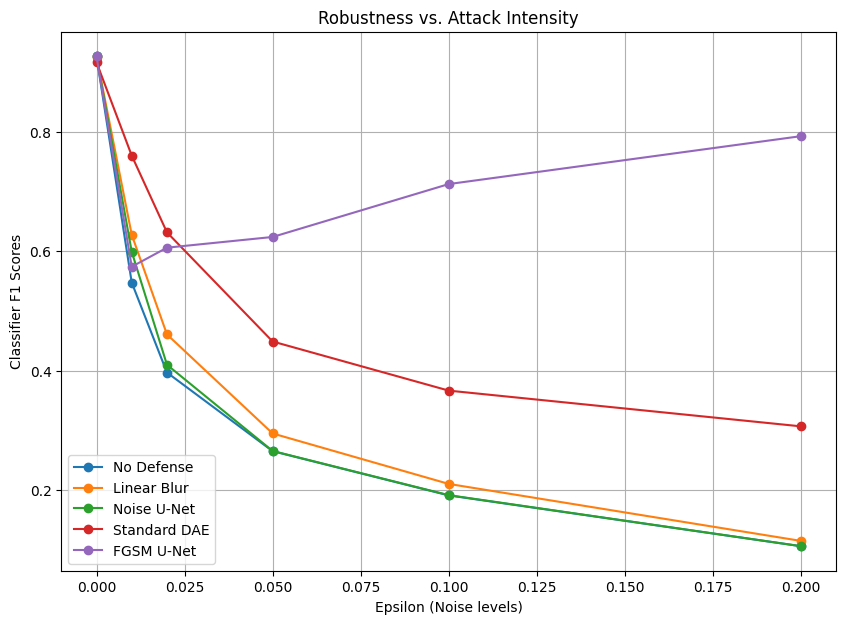

In [59]:
def evaluate_defense_f1(model, data, labels):
    preds = model.predict(data, verbose=0)
    # Using 'macro' average to ensure equal class weighting
    score = f1_score(labels, np.argmax(preds, axis=1), average='macro')
    return score

epsilons = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2]
stress_results = {"Epsilon": epsilons, "No Defense": [], "Linear Blur": [], "Noise U-Net":[], "Standard DAE": [], "FGSM U-Net": []}

for eps in epsilons:
    print(f"Stress testing epsilon: {eps}...")
    # Generate attack at given epsilon
    x_adv = generate_fgsm_in_batches(classifier, X_test, y_test, epsilon=eps, batch_size=128)

    # Evaluate No Defense (No image cleaning)
    stress_results["No Defense"].append(evaluate_defense_f1(classifier, x_adv, y_test))

    # Evaluate Linear Blur
    x_blur = apply_linear_blur(x_adv)
    stress_results["Linear Blur"].append(evaluate_defense_f1(classifier, x_blur, y_test))

    # Evaluate Noise Trained U-Net
    x_noise_unet = autoencoder.predict(x_adv, verbose=0)
    stress_results["Noise U-Net"].append(evaluate_defense_f1(classifier, x_noise_unet, y_test))

    # Evaluate Standard DAE
    x_std = standard_dae.predict(x_adv, verbose=0)
    stress_results["Standard DAE"].append(evaluate_defense_f1(classifier, x_std, y_test))

    # Evaluate FGSM Trained U-Net
    x_fgsm_unet = adversarial_autoencoder.predict(x_adv, verbose=0)
    stress_results["FGSM U-Net"].append(evaluate_defense_f1(classifier, x_fgsm_unet, y_test))

# Plot results
plt.figure(figsize=(10, 7))
for key in list(stress_results.keys())[1:]:
    plt.plot(stress_results["Epsilon"], stress_results[key], marker='o', label=key)

plt.title("Robustness vs. Attack Intensity")
plt.xlabel("Epsilon (Noise levels)")
plt.ylabel("Classifier F1 Scores")
plt.legend()
plt.grid(True)
plt.show()